# **Important Rules and Restrictions**

Use of the following libraries is strictly prohibited:

- NLTK  
- spaCy  
- HuggingFace Tokenizers  
- SentencePiece  
- Urduhack  
- Stanza  
- Polyglot  
- Gensim Language Models  
- sklearn CountVectorizer / TfidfVectorizer  

Violation will result in zero marks.

### **Allowed Libraries**
Students may use:

- Python Standard Functions 
- Regex  
- NumPy  
- Pandas  
- BeautifulSoup / Requests / Scrapy / Selenium (For use of Scraping only)  
- Matplotlib  

## **Part 1: BBC Urdu Dataset Collection and Preprocessing**
In this part, BBC Urdu news articles are collected and prepared into a clean dataset using normalization and custom preprocessing tools. The output of this part will be reused directly in Part 2.

News articles must be scraped from:
https://www.bbc.com/urdu

Students must scrape:
- Minimum: 200 articles
- Maximum: 300 articles

Each article must be complete and properly structured.

Article metadata must be stored in a JSON file with the following constraints:
- Each article must be numbered
- Article numbers must be unique
- Article numbers must match TXT files
- Article body must not be included

### ***Format Example***
```json
{
  "1": {
    "title": "پاکستان میں مہنگائی کی شرح میں اضافہ",
    "publish_date": "2024-01-15"
  },
  "2": {
    "title": "کراچی میں بارش کے بعد صورتحال",
    "publish_date": "2024-02-02"
  }
}

In [2]:
import requests
from bs4 import BeautifulSoup
import json
import time
import re
import os


# BBC Urdu Scraper


HEADERS = { # basically fakes a chrome browser so BBC doesnt block requests
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept-Language': 'ur,en;q=0.9',
}

BASE_URL = "https://www.bbc.com"

# BBC Urdu category topic pages
CATEGORY_URLS = [
    "https://www.bbc.com/urdu",
    "https://www.bbc.com/urdu/topics/cjgn7n9zzq7t",   # Pakistan
    "https://www.bbc.com/urdu/topics/cl8l9mveql2t",   # آس پاس
    "https://www.bbc.com/urdu/topics/cw57v2pmll9t",   # ورلڈ
    "https://www.bbc.com/urdu/topics/c340q0p2585t",   # کھیل
    "https://www.bbc.com/urdu/topics/ckdxnx900n5t",   # فن فنکار
    "https://www.bbc.com/urdu/topics/c40379e2ymxt",   # سائنس
]

TARGET_ARTICLES = 250  # aim for 250, between 200-300

def collect_article_urls():
    """Collect unique article URLs from BBC Urdu category pages."""
    article_urls = set()
    
    for cat_url in CATEGORY_URLS:
        try:
            print(f"Scraping category: {cat_url}")
            response = requests.get(cat_url, headers=HEADERS, timeout=15)
            response.raise_for_status()
            soup = BeautifulSoup(response.content, 'html.parser')
            
            # find all links that point to /urdu/articles/
            for link in soup.find_all('a', href=True):
                href = link['href']
                if '/urdu/articles/' in href:
                    # build full URL
                    if href.startswith('/'):
                        full_url = BASE_URL + href
                    elif href.startswith('http'):
                        full_url = href
                    else:
                        continue
                    # clean URL (remove query params)
                    full_url = full_url.split('?')[0].split('#')[0]
                    article_urls.add(full_url)
            
            print(f"  Found {len(article_urls)} unique articles so far")
            time.sleep(1)
            
        except Exception as e:
            print(f"  Error scraping {cat_url}: {e}")
            continue
    
    # If not enough from categories, also try topic sub-pages
    if len(article_urls) < TARGET_ARTICLES:
        # Try older article pages by appending page parameter
        for cat_url in CATEGORY_URLS[1:]:  # skip main page
            if len(article_urls) >= TARGET_ARTICLES:
                break
            try:
                page_url = cat_url + "?page=2"
                print(f"Scraping page 2: {page_url}")
                response = requests.get(page_url, headers=HEADERS, timeout=15)
                if response.status_code == 200:
                    soup = BeautifulSoup(response.content, 'html.parser')
                    for link in soup.find_all('a', href=True):
                        href = link['href']
                        if '/urdu/articles/' in href:
                            if href.startswith('/'):
                                full_url = BASE_URL + href
                            elif href.startswith('http'):
                                full_url = href
                            else:
                                continue
                            full_url = full_url.split('?')[0].split('#')[0]
                            article_urls.add(full_url)
                    print(f"  Found {len(article_urls)} unique articles so far")
                time.sleep(1)
            except Exception as e:
                print(f"  Error: {e}")
                continue
    
    return list(article_urls)

def scrape_article(url):
    """Scrape a single BBC Urdu article: title, date, body."""
    try:
        response = requests.get(url, headers=HEADERS, timeout=15)
        response.raise_for_status()
        soup = BeautifulSoup(response.content, 'html.parser')
        
        # ---- Title ----
        title = None
        h1 = soup.find('h1')
        if h1:
            title = h1.get_text(strip=True)
        
        if not title:
            return None
        
        # ---- Publish Date ----
        publish_date = "N/A"
        time_tag = soup.find('time')
        if time_tag:
            dt = time_tag.get('datetime', '')
            if dt:
                publish_date = dt[:10]  # YYYY-MM-DD
            else:
                publish_date = time_tag.get_text(strip=True)
        
        # ---- Article Body ----
        body_paragraphs = []
        
        # BBC uses article tag with main content
        article_tag = soup.find('article')
        if article_tag:
            # Get all paragraph tags within article
            for p in article_tag.find_all('p'):
                text = p.get_text(strip=True)
                if text and len(text) > 10:  # skip very short artifacts
                    body_paragraphs.append(text)
        
        # Fallback: if no article tag, try main content area
        if not body_paragraphs:
            main = soup.find('main')
            if main:
                for p in main.find_all('p'):
                    text = p.get_text(strip=True)
                    if text and len(text) > 10:
                        body_paragraphs.append(text)
        
        # Join paragraphs
        body = '\n'.join(body_paragraphs)
        
        # Skip if body is too short (not a real article)
        if len(body) < 100:
            return None
        
        return {
            'title': title,
            'publish_date': publish_date,
            'body': body,
            'url': url
        }
        
    except Exception as e:
        print(f"  Error scraping article {url}: {e}")
        return None


# Step 1: Collect all article URLs

print("=" * 60)
print("STEP 1: Collecting article URLs from BBC Urdu...")
print("=" * 60)
article_urls = collect_article_urls()
print(f"\nTotal unique article URLs found: {len(article_urls)}")

# Step 2: Scrape each article
print("\n" + "=" * 60)
print("STEP 2: Scraping individual articles...")
print("=" * 60)

articles = {}
article_num = 1

for i, url in enumerate(article_urls):
    if article_num > TARGET_ARTICLES:
        break
    
    if (i + 1) % 10 == 0:
        print(f"  Progress: {i+1}/{len(article_urls)} URLs processed, {len(articles)} articles collected")
    
    article_data = scrape_article(url)
    
    if article_data:
        articles[str(article_num)] = article_data
        article_num += 1
    
    time.sleep(1.5)  # polite delay between requests

print(f"\nTotal articles successfully scraped: {len(articles)}")

# Step 3: Save metadata.json (NO body text)
# metadata.json will contain only title and publish_date for each article, indexed by article number
# articles_full.json, everything including the body, used internally by later cells
metadata = {}
for num, data in articles.items():
    metadata[num] = {
        "title": data["title"],
        "publish_date": data["publish_date"]
    }

output_dir = r"d:\Assignments\SEMESTER#06\NLP\Assignment 01"

metadata_path = os.path.join(output_dir, "metadata.json")
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f"\nMetadata saved to: {metadata_path}")
print(f"Sample entry: {json.dumps(metadata.get('1', {}), ensure_ascii=False, indent=2)}")

# Save full articles data for later use (temporary, includes body)
articles_path = os.path.join(output_dir, "articles_full.json")
with open(articles_path, 'w', encoding='utf-8') as f:
    json.dump(articles, f, ensure_ascii=False, indent=2)

print(f"Full articles data saved to: {articles_path}")
print(f"\n✓ Scraping complete! {len(articles)} articles collected.")

STEP 1: Collecting article URLs from BBC Urdu...
Scraping category: https://www.bbc.com/urdu
  Found 44 unique articles so far
Scraping category: https://www.bbc.com/urdu/topics/cjgn7n9zzq7t
  Found 52 unique articles so far
Scraping category: https://www.bbc.com/urdu/topics/cl8l9mveql2t
  Found 62 unique articles so far
Scraping category: https://www.bbc.com/urdu/topics/cw57v2pmll9t
  Found 74 unique articles so far
Scraping category: https://www.bbc.com/urdu/topics/c340q0p2585t
  Found 89 unique articles so far
Scraping category: https://www.bbc.com/urdu/topics/ckdxnx900n5t
  Found 109 unique articles so far
Scraping category: https://www.bbc.com/urdu/topics/c40379e2ymxt
  Found 120 unique articles so far
Scraping page 2: https://www.bbc.com/urdu/topics/cjgn7n9zzq7t?page=2
  Found 136 unique articles so far
Scraping page 2: https://www.bbc.com/urdu/topics/cl8l9mveql2t?page=2
  Found 156 unique articles so far
Scraping page 2: https://www.bbc.com/urdu/topics/cw57v2pmll9t?page=2
  Foun

### ***raw.txt File***
This file must contain:
- Raw scraped article content
- No cleaning or normalization
- One article per block
- Each article must start with its article number

### ***Example***
```json
[1]
یہ خبر بی بی سی اردو سے حاصل کی گئی ہے...

[2]
کراچی میں بارش کے بعد صورتحال خراب ہو گئی...

In [3]:
# Save raw.txt - Raw scraped articles (NO cleaning/normalization)

import json
import os

output_dir = r"d:\Assignments\SEMESTER#06\NLP\Assignment 01"

# Load the full articles data
with open(os.path.join(output_dir, "articles_full.json"), 'r', encoding='utf-8') as f:
    articles = json.load(f)

# Write raw.txt - each article starts with its number, raw content, no processing
raw_path = os.path.join(output_dir, "raw.txt")
with open(raw_path, 'w', encoding='utf-8') as f:
    for num in sorted(articles.keys(), key=int):
        body = articles[num]['body']
        f.write(f"[{num}]\n")
        f.write(body)
        f.write("\n\n")

print(f"raw.txt saved to: {raw_path}")
print(f"Total articles in raw.txt: {len(articles)}")

# Show a sample
print("\n--- Sample (Article 1) ---")
body_preview = articles['1']['body'][:300]
print(f"[1]\n{body_preview}...")

raw.txt saved to: d:\Assignments\SEMESTER#06\NLP\Assignment 01\raw.txt
Total articles in raw.txt: 233

--- Sample (Article 1) ---
[1]
،تصویر کا ذریعہICC via Getty Images
ٹی 20 انٹرنیشنل میچز میں بہت کم ایسا ہوتا ہے کہ مقابلے کا فیصلہ سپر اوور میں ہو اور ایسا تو بالکل ہی شاذونادر ہوتا ہے کہ سپر اوور میں بھی فیصلہ نہ ہو پائے اور دوسرا سپر اوور کھیلنے کی نوبت آئے۔
بدھ کے روز ٹی ٹوئنٹی ورلڈ کپ میں جنوبی افریقہ اور افغانستان کے درمیان ...


## ***cleaned.txt File***

This file must contain:
- Fully preprocessed data
- Normalized Urdu text
- Noise removed
- Sentence segmented
- Ready for language model training
- Article numbering matching raw.txt and JSON

**Refer to the given Assignment PDF Document for the data cleaning and normalizing techniques**

In [4]:
# Data Cleaning & Normalization Pipeline + cleaned.txt

# implemented a 5 stage cleaning pipeline to produce cleaned.txt

import re
import json
import os

output_dir = r"d:\Assignments\SEMESTER#06\NLP\Assignment 01"

# Load the full articles data
with open(os.path.join(output_dir, "articles_full.json"), 'r', encoding='utf-8') as f:
    articles = json.load(f)

# 3.1 Diacritics Removal
def remove_diacritics(text):
    """
    Remove Urdu/Arabic diacritics (zabar, zer, pesh, tashdeed, etc.)
    Unicode ranges: \u0610-\u061A, \u064B-\u065F, \u0670
    """
    # Arabic diacritics
    text = re.sub(r'[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06DC\u06DF-\u06E4\u06E7\u06E8\u06EA-\u06ED]', '', text)
    return text

# 3.2 Noise Removal
def remove_noise(text):
    """
    Remove URLs, emojis, HTML artifacts, web navigation text, and special symbols.
    """
    # Remove URLs
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    
    # Remove emojis (common emoji unicode ranges)
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "\U0001f926-\U0001f937"
        "\U00010000-\U0010ffff"
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub('', text)
    
    # Remove HTML tags if any remain
    text = re.sub(r'<[^>]+>', '', text)
    
    # Remove common BBC navigation/metadata artifacts
    text = re.sub(r'(تصویر کا ذریعہ|تصویر کا کیپشن|Getty Images|AFP|Reuters|EPA|BBC|PA Media)', '', text)
    text = re.sub(r'(مصنف|عہدہ|مطالعے کا وقت|دورانیہ)', '', text)
    text = re.sub(r'\d+\s*(منٹ|گھنٹے?|سیکنڈ)\s*(قبل)?', '', text)
    
    # Remove special characters but keep Urdu text, numbers, and Urdu punctuation
    # Keep: Urdu letters (\u0600-\u06FF), Urdu-extended (\u0750-\u077F), 
    #        spaces, Urdu punctuation (۔ ، ؟ !)
    text = re.sub(r'[^\u0600-\u06FF\u0750-\u077F\s۰-۹0-9؟،۔!٪\.\,]', ' ', text)
    
    return text

# 3.3 Removal of Non-Urdu Text
def remove_non_urdu(text):
    """
    Remove English text, Roman Urdu, and any non-Urdu script content.
    Keep only Urdu script characters + Urdu digits + Urdu punctuation.
    """
    # Remove English words (Latin characters)
    text = re.sub(r'[a-zA-Z]+', ' ', text)
    
    # Remove standalone English/Arabic digits but keep Urdu digits
    # We'll handle number replacement in tokenizer with <NUM>
    
    # Remove any remaining non-Urdu characters except allowed ones
    text = re.sub(r'[^\u0600-\u06FF\u0750-\u077F\s۰-۹0-9؟،۔!]', ' ', text)
    
    return text

# 3.4 Sentence Segmentation
# this basically splits text into sentences using Urdu sentence-ending punctuation like dash

def segment_sentences(text):
    """
    Split text into sentences using Urdu punctuation marks.
    Urdu sentence enders: ۔ (full stop), ؟ (question mark), ! (exclamation)
    """
    # Split on Urdu sentence-ending punctuation
    # Keep the delimiter with the sentence
    sentences = re.split(r'(?<=[۔؟!])\s*', text)
    
    # Clean and filter
    clean_sentences = []
    for sent in sentences:
        sent = sent.strip()
        if sent and len(sent) > 5:  # Skip very short fragments
            clean_sentences.append(sent)
    
    return clean_sentences

# 3.5 Whitespace and Formatting Normalization
def normalize_whitespace(text):
    """
    Normalize whitespace: collapse multiple spaces, fix line breaks,
    ensure consistent spacing.
    """
    # Replace multiple newlines with single newline
    text = re.sub(r'\n+', '\n', text)
    
    # Replace multiple spaces with single space
    text = re.sub(r'[ \t]+', ' ', text)
    
    # Remove leading/trailing whitespace per line
    lines = text.split('\n')
    lines = [line.strip() for line in lines if line.strip()]
    text = '\n'.join(lines)
    
    # Final strip
    text = text.strip()
    
    return text

# Full Cleaning Pipeline
def clean_article(text):
    """Apply all cleaning steps in sequence."""
    text = remove_diacritics(text)
    text = remove_noise(text)
    text = remove_non_urdu(text)
    text = normalize_whitespace(text)
    
    # Sentence segmentation
    sentences = segment_sentences(text)
    
    # Rejoin with newlines (one sentence per line)
    cleaned = '\n'.join(sentences)
    
    return cleaned

# Apply cleaning to all articles and save cleaned.txt
print("Applying cleaning pipeline to all articles...\n")

cleaned_articles = {}
for num in sorted(articles.keys(), key=int):
    body = articles[num]['body']
    cleaned_body = clean_article(body)
    cleaned_articles[num] = cleaned_body

# Save cleaned.txt
cleaned_path = os.path.join(output_dir, "cleaned.txt")
with open(cleaned_path, 'w', encoding='utf-8') as f:
    for num in sorted(cleaned_articles.keys(), key=int):
        f.write(f"[{num}]\n")
        f.write(cleaned_articles[num])
        f.write("\n\n")

print(f"cleaned.txt saved to: {cleaned_path}")
print(f"Total articles in cleaned.txt: {len(cleaned_articles)}")

# Show before/after comparison
print("\n" + "=" * 60)
print("BEFORE (Raw) - Article 1 (first 200 chars):")
print("=" * 60)
print(articles['1']['body'][:200])

print("\n" + "=" * 60)
print("AFTER (Cleaned) - Article 1 (first 300 chars):")
print("=" * 60)
print(cleaned_articles['1'][:300])

# Show cleaning stats
raw_total_chars = sum(len(articles[n]['body']) for n in articles)
clean_total_chars = sum(len(cleaned_articles[n]) for n in cleaned_articles)
print(f"\n--- Cleaning Stats ---")
print(f"Total raw characters: {raw_total_chars:,}")
print(f"Total cleaned characters: {clean_total_chars:,}")
print(f"Reduction: {((raw_total_chars - clean_total_chars) / raw_total_chars * 100):.1f}%")

# Save cleaned articles for later use
cleaned_full_path = os.path.join(output_dir, "cleaned_articles.json")
with open(cleaned_full_path, 'w', encoding='utf-8') as f:
    json.dump(cleaned_articles, f, ensure_ascii=False, indent=2)
print(f"\nCleaned articles JSON saved for reuse in Part 2.")

Applying cleaning pipeline to all articles...

cleaned.txt saved to: d:\Assignments\SEMESTER#06\NLP\Assignment 01\cleaned.txt
Total articles in cleaned.txt: 233

BEFORE (Raw) - Article 1 (first 200 chars):
،تصویر کا ذریعہICC via Getty Images
ٹی 20 انٹرنیشنل میچز میں بہت کم ایسا ہوتا ہے کہ مقابلے کا فیصلہ سپر اوور میں ہو اور ایسا تو بالکل ہی شاذونادر ہوتا ہے کہ سپر اوور میں بھی فیصلہ نہ ہو پائے اور دوسرا

AFTER (Cleaned) - Article 1 (first 300 chars):
،
ٹی 20 انٹرنیشنل میچز میں بہت کم ایسا ہوتا ہے کہ مقابلے کا فیصلہ سپر اوور میں ہو اور ایسا تو بالکل ہی شاذونادر ہوتا ہے کہ سپر اوور میں بھی فیصلہ نہ ہو پائے اور دوسرا سپر اوور کھیلنے کی نوبت آئے۔
بدھ کے روز ٹی ٹوئنٹی ورلڈ کپ میں جنوبی افریقہ اور افغانستان کے درمیان ہونے والے میچ میں ایسا ہی ہوا اور 

--- Cleaning Stats ---
Total raw characters: 1,549,158
Total cleaned characters: 1,507,101
Reduction: 2.7%

Cleaned articles JSON saved for reuse in Part 2.


## ***Custom Urdu Tokenizer***

The tokenizer must handle:
- Word boundaries
- Punctuation
- Postpositions
- Numbers and special tokens

All numbers must be replaced with `<NUM>`.

Input:

پاکستان میں میں بارش ہوئی  
2024  

Output:

پاکستان | میں | میں | بارش | ہوئی  
`<NUM>`

In [5]:
# Custom Urdu Tokenizer
# This cell converts cleaned article text into a list of discrete tokens (individual words, 
# punctuation marks) which is the representation needed by the language models in Part 2.
import re
import json
import os

output_dir = r"d:\Assignments\SEMESTER#06\NLP\Assignment 01"

# Load cleaned articles
with open(os.path.join(output_dir, "cleaned_articles.json"), 'r', encoding='utf-8') as f:
    cleaned_articles = json.load(f)

# Urdu punctuation marks to split on
URDU_PUNCTUATION = set('۔،؟!٫٪')

# Common Urdu postpositions (to handle word boundaries correctly)
POSTPOSITIONS = {'کا', 'کی', 'کے', 'کو', 'سے', 'میں', 'نے', 'پر', 'تک', 'کیلئے', 
                 'لئے', 'بعد', 'پہلے', 'ساتھ', 'بغیر', 'خلاف', 'بارے', 'ذریعے',
                 'دوران', 'باوجود', 'مطابق', 'نزدیک', 'بجائے', 'علاوہ'}

def urdu_tokenize(text):
    """
    Custom Urdu tokenizer that handles:
    1. Word boundaries (space-based + punctuation-based)
    2. Urdu punctuation (۔ ، ؟ !)
    3. Postpositions (kept as separate tokens)
    4. Numbers replaced with <NUM>
    """
    # Step 1: Replace all numbers (English 0-9 and Urdu ۰-۹) with <NUM>
    text = re.sub(r'[0-9۰-۹]+', '<NUM>', text)
    
    # Step 2: Add spaces around Urdu punctuation so they become separate tokens
    for punct in URDU_PUNCTUATION:
        text = text.replace(punct, f' {punct} ')
    
    # Step 3: Split on whitespace
    raw_tokens = text.split()
    
    # Step 4: Clean tokens
    tokens = []
    for token in raw_tokens:
        token = token.strip()
        if not token:
            continue
        
        # Keep punctuation as separate tokens
        if token in URDU_PUNCTUATION:
            tokens.append(token)
            continue
        
        # Keep <NUM> token
        if token == '<NUM>':
            tokens.append(token)
            continue
        
        # Keep Urdu words (must contain at least one Urdu character)
        if re.search(r'[\u0600-\u06FF]', token):
            tokens.append(token)
            continue
        
        # Keep <NUM> even if part of compound
        if '<NUM>' in token:
            tokens.append(token)
            continue
    
    return tokens

def tokenize_article(text):
    """Tokenize a full article (may contain multiple sentences)."""
    lines = text.split('\n')
    all_tokens = []
    for line in lines:
        line = line.strip()
        if line:
            tokens = urdu_tokenize(line)
            all_tokens.extend(tokens)
    return all_tokens

# Apply tokenization to all cleaned articles
print("Tokenizing all cleaned articles...\n")

tokenized_articles = {}
total_tokens = 0

for num in sorted(cleaned_articles.keys(), key=int):
    text = cleaned_articles[num]
    tokens = tokenize_article(text)
    tokenized_articles[num] = tokens
    total_tokens += len(tokens)

print(f"Total articles tokenized: {len(tokenized_articles)}")
print(f"Total tokens across all articles: {total_tokens:,}")

# Build vocabulary
vocab = set()
for num, tokens in tokenized_articles.items():
    vocab.update(tokens)
print(f"Vocabulary size: {len(vocab):,}")

# Show sample tokenization
print("\n" + "=" * 60)
print("TOKENIZATION DEMO:")
print("=" * 60)

demo_text = "پاکستان میں میں بارش ہوئی\n2024"
print(f"\nInput:\n{demo_text}")
demo_tokens = urdu_tokenize(demo_text)
print(f"\nOutput:\n{' | '.join(demo_tokens)}")

print("\n--- Article 1 (first 30 tokens) ---")
print(' | '.join(tokenized_articles['1'][:30]))

# Count <NUM> replacements
num_count = sum(1 for num_key in tokenized_articles for t in tokenized_articles[num_key] if t == '<NUM>')
print(f"\nTotal <NUM> tokens: {num_count}")

# Save tokenized data for Part 2
tokenized_path = os.path.join(output_dir, "tokenized_articles.json")
with open(tokenized_path, 'w', encoding='utf-8') as f:
    json.dump(tokenized_articles, f, ensure_ascii=False, indent=2)
print(f"\nTokenized articles saved to: {tokenized_path}")

Tokenizing all cleaned articles...

Total articles tokenized: 233
Total tokens across all articles: 347,096
Vocabulary size: 13,936

TOKENIZATION DEMO:

Input:
پاکستان میں میں بارش ہوئی
2024

Output:
پاکستان | میں | میں | بارش | ہوئی | <NUM>

--- Article 1 (first 30 tokens) ---
، | ٹی | <NUM> | انٹرنیشنل | میچز | میں | بہت | کم | ایسا | ہوتا | ہے | کہ | مقابلے | کا | فیصلہ | سپر | اوور | میں | ہو | اور | ایسا | تو | بالکل | ہی | شاذونادر | ہوتا | ہے | کہ | سپر | اوور

Total <NUM> tokens: 2921

Tokenized articles saved to: d:\Assignments\SEMESTER#06\NLP\Assignment 01\tokenized_articles.json


## ***Custom Urdu Stemmer***
The stemmer must remove common Urdu suffixes.

Input:
لڑکیوں نے کتابیں پڑھیں  

Output:
لڑکی | کتاب | پڑھ


In [6]:
# Custom Urdu Stemmer

import re
import json
import os

output_dir = r"d:\Assignments\SEMESTER#06\NLP\Assignment 01"

# Load tokenized articles
with open(os.path.join(output_dir, "tokenized_articles.json"), 'r', encoding='utf-8') as f:
    tokenized_articles = json.load(f)


# Urdu Suffix Rules (ordered longest first for greedy matching)


# Suffixes sorted by length (longest first to avoid partial matches)
URDU_SUFFIXES = [
    # 4+ character suffixes
    'یاتی',    # organizational
    'اتیں',    # plural verb
    'ئیاں',    # feminine plural
    'یانی',    # adjectival
    # 3 character suffixes
    'یوں',     # oblique plural (لڑکیوں)
    'یاں',     # feminine plural (لڑکیاں)
    'وں',      # oblique plural (لوگوں) - moved to 2-char
    'ائی',     # verbal noun
    'ائے',     # subjunctive
    'ئیں',     # feminine plural verb
    'ئیے',     # imperative
    'تیں',     # feminine past habitual
    'ائیں',    # plural subjunctive
    'اتا',     # masculine habitual
    'اتی',     # feminine habitual
    'اتے',     # plural habitual
    # 2 character suffixes
    'وں',      # oblique plural
    'یں',      # plural verbs (پڑھیں)
    'ات',      # plural noun (ملاقات → ملاق not good, be careful)
    'ان',      # plural (درختان)
    'ین',      # plural
    'تا',      # masculine habitual (کرتا)
    'تی',      # feminine habitual (کرتی)
    'تے',      # plural habitual (کرتے)
    'نا',      # infinitive (کرنا)
    'نی',      # feminine infinitive
    'نے',      # ergative/infinitive oblique
    'ئی',      # past perfect fem (ہوئی)
    'ئے',      # past perfect plural (ہوئے)
    'اں',      # plural marker
    'یں',      # verb plural
    'وا',      # causative
    'کر',      # conjunctive participle
    'یا',      # past tense (کیا, گیا)
    'ہا',      # verbal adjective
    'ہی',      # emphatic
    'ہے',      # auxiliary
    'یے',      # imperative
    # 1 character suffixes (apply cautiously)
    'ی',       # feminine marker / adjective
    'ے',       # masculine plural / oblique
    'ا',       # masculine singular
    'و',       # vocative/plural
]

# Minimum stem length to avoid over-stemming
MIN_STEM_LENGTH = 2

# Words that should NOT be stemmed (stop words, common short words)
STEM_EXCEPTIONS = {
    'کا', 'کی', 'کے', 'کو', 'سے', 'میں', 'نے', 'پر', 'تک', 'یا',
    'اور', 'ہے', 'ہیں', 'تھا', 'تھی', 'تھے', 'گا', 'گی', 'گے',
    'جو', 'کہ', 'اگر', 'تو', 'بھی', 'ہی', 'نہ', 'نہیں', 'مگر',
    'یہ', 'وہ', 'اس', 'ان', 'جب', 'کب', 'کیا', 'کیوں', 'کیسے',
    'ابھی', 'پھر', 'کم', 'زیادہ', 'بہت', 'کچھ', 'سب', 'ہر',
    '<NUM>', '۔', '،', '؟', '!',
}

def urdu_stem(word):
    """
    Custom Urdu stemmer: removes common suffixes to obtain root form.
    Uses longest-match-first strategy with minimum stem length constraint.
    """
    # Don't stem exceptions, punctuation, or special tokens
    if word in STEM_EXCEPTIONS:
        return word
    
    # Don't stem very short words
    if len(word) <= MIN_STEM_LENGTH:
        return word
    
    # Try removing suffixes (longest first)
    for suffix in URDU_SUFFIXES:
        if word.endswith(suffix):
            stem = word[:-len(suffix)]
            # Ensure minimum stem length
            if len(stem) >= MIN_STEM_LENGTH:
                return stem
    
    return word

def stem_tokens(tokens):
    """Apply stemming to a list of tokens."""
    return [urdu_stem(token) for token in tokens]


# Apply stemming to all tokenized articles

print("Stemming all tokenized articles...\n")

stemmed_articles = {}
total_stemmed = 0
changed_count = 0

for num in sorted(tokenized_articles.keys(), key=int):
    tokens = tokenized_articles[num]
    stemmed = stem_tokens(tokens)
    stemmed_articles[num] = stemmed
    total_stemmed += len(stemmed)
    changed_count += sum(1 for o, s in zip(tokens, stemmed) if o != s)

print(f"Total articles stemmed: {len(stemmed_articles)}")
print(f"Total tokens processed: {total_stemmed:,}")
print(f"Tokens modified by stemming: {changed_count:,} ({changed_count/total_stemmed*100:.1f}%)")

# Show demo
print("\n" + "=" * 60)
print("STEMMING DEMO:")
print("=" * 60)

demo_input = "لڑکیوں نے کتابیں پڑھیں"
demo_tokens = demo_input.split()
demo_stemmed = stem_tokens(demo_tokens)
print(f"\nInput: {demo_input}")
print(f"Output: {' | '.join(demo_stemmed)}")

# More examples
examples = ['پاکستانی', 'حکومتوں', 'انتخابات', 'کھیلتا', 'لکھتی', 'بچوں', 'ملکوں', 'کرتے']
print("\n--- More Examples ---")
for word in examples:
    print(f"  {word} → {urdu_stem(word)}")

# Show Article 1 comparison
print("\n--- Article 1 (first 20 tokens) ---")
print("Original: ", ' | '.join(tokenized_articles['1'][:20]))
print("Stemmed:  ", ' | '.join(stemmed_articles['1'][:20]))

# Save stemmed data
stemmed_path = os.path.join(output_dir, "stemmed_articles.json")
with open(stemmed_path, 'w', encoding='utf-8') as f:
    json.dump(stemmed_articles, f, ensure_ascii=False, indent=2)
print(f"\nStemmed articles saved to: {stemmed_path}")

Stemming all tokenized articles...

Total articles stemmed: 233
Total tokens processed: 347,096
Tokens modified by stemming: 94,439 (27.2%)

STEMMING DEMO:

Input: لڑکیوں نے کتابیں پڑھیں
Output: لڑک | نے | کتاب | پڑھ

--- More Examples ---
  پاکستانی → پاکستا
  حکومتوں → حکومت
  انتخابات → انتخاب
  کھیلتا → کھیل
  لکھتی → لکھ
  بچوں → بچ
  ملکوں → ملک
  کرتے → کر

--- Article 1 (first 20 tokens) ---
Original:  ، | ٹی | <NUM> | انٹرنیشنل | میچز | میں | بہت | کم | ایسا | ہوتا | ہے | کہ | مقابلے | کا | فیصلہ | سپر | اوور | میں | ہو | اور
Stemmed:   ، | ٹی | <NUM> | انٹرنیشنل | میچز | میں | بہت | کم | ایس | ہو | ہے | کہ | مقابل | کا | فیصلہ | سپر | اوور | میں | ہو | اور

Stemmed articles saved to: d:\Assignments\SEMESTER#06\NLP\Assignment 01\stemmed_articles.json


## ***Custom Urdu Lemmatizer***

The lemmatizer is restricted to:
- Plural normalization
- Gender normalization

Plural:
- لڑکیاں -> لڑکی  
- کتابوں -> کتاب  

Gender:
- اچھی -> اچھا  
- بڑی -> بڑا

In [ ]:
# Custom Urdu Lemmatizer

# Restricted to: Plural normalization + Gender normalization

import re
import json
import os

output_dir = r"d:\Assignments\SEMESTER#06\NLP\Assignment 01"

# Load tokenized articles
with open(os.path.join(output_dir, "tokenized_articles.json"), 'r', encoding='utf-8') as f:
    tokenized_articles = json.load(f)

# 1. PLURAL NORMALIZATION - Lookup dictionary
PLURAL_TO_SINGULAR = {
    # Common noun plurals
    'لڑکیاں': 'لڑکی',
    'لڑکیوں': 'لڑکی',
    'لڑکے': 'لڑکا',
    'لڑکوں': 'لڑکا',
    'کتابیں': 'کتاب',
    'کتابوں': 'کتاب',
    'عورتیں': 'عورت',
    'عورتوں': 'عورت',
    'بچیاں': 'بچی',
    'بچیوں': 'بچی',
    'بچے': 'بچہ',
    'بچوں': 'بچہ',
    'لوگوں': 'لوگ',
    'ملکوں': 'ملک',
    'شہروں': 'شہر',
    'سالوں': 'سال',
    'دنوں': 'دن',
    'گھروں': 'گھر',
    'آنکھیں': 'آنکھ',
    'آنکھوں': 'آنکھ',
    'باتیں': 'بات',
    'باتوں': 'بات',
    'راتیں': 'رات',
    'راتوں': 'رات',
    'بہنیں': 'بہن',
    'بہنوں': 'بہن',
    'خبریں': 'خبر',
    'خبروں': 'خبر',
    'تصویریں': 'تصویر',
    'تصویروں': 'تصویر',
    'قیمتیں': 'قیمت',
    'قیمتوں': 'قیمت',
    'حکومتیں': 'حکومت',
    'حکومتوں': 'حکومت',
    'جماعتیں': 'جماعت',
    'جماعتوں': 'جماعت',
    'پارٹیوں': 'پارٹی',
    'پارٹیاں': 'پارٹی',
    'فوجیوں': 'فوجی',
    'انتخابات': 'انتخاب',
    'ملاقاتیں': 'ملاقات',
    'مسائل': 'مسئلہ',
    'ممالک': 'ملک',
    'ادارے': 'ادارہ',
    'اداروں': 'ادارہ',
    'واقعات': 'واقعہ',
    'معاملات': 'معاملہ',
    'حملے': 'حملہ',
    'حملوں': 'حملہ',
    'نتائج': 'نتیجہ',
    'مقامات': 'مقام',
    'الزامات': 'الزام',
    'حقوق': 'حق',
    'امور': 'امر',
    'علاقے': 'علاقہ',
    'علاقوں': 'علاقہ',
    'ادویات': 'دوائی',
    'جانوروں': 'جانور',
    'کھلاڑیوں': 'کھلاڑی',
    'سیاستدانوں': 'سیاستدان',
    'رہنماؤں': 'رہنما',
    'وزیروں': 'وزیر',
    'افسروں': 'افسر',
    'ارکان': 'رکن',
    'اخبارات': 'اخبار',
    'طیارے': 'طیارہ',
    'طیاروں': 'طیارہ',
    'دروازے': 'دروازہ',
    'دروازوں': 'دروازہ',
    'مظاہرے': 'مظاہرہ',
    'مظاہروں': 'مظاہرہ',
    'فیصلے': 'فیصلہ',
    'فیصلوں': 'فیصلہ',
}

# 2. GENDER NORMALIZATION - Feminine to base (masculine) form
FEMININE_TO_BASE = {
    # Common adjectives (feminine → masculine base)
    'اچھی': 'اچھا',
    'بڑی': 'بڑا',
    'چھوٹی': 'چھوٹا',
    'لمبی': 'لمبا',
    'موٹی': 'موٹا',
    'پتلی': 'پتلا',
    'کالی': 'کالا',
    'گوری': 'گورا',
    'نئی': 'نیا',
    'پرانی': 'پرانا',
    'بری': 'برا',
    'سچی': 'سچا',
    'جھوٹی': 'جھوٹا',
    'کچی': 'کچا',
    'پکی': 'پکا',
    'صاف': 'صاف',  # no change
    'گندی': 'گندا',
    'خالی': 'خالا',
    'بھاری': 'بھاری',  # no change (ends in ی but stays)
    'پوری': 'پورا',
    'آدھی': 'آدھا',
    'سیدھی': 'سیدھا',
    'اُلٹی': 'اُلٹا',
    'اونچی': 'اونچا',
    'نیچی': 'نیچا',
    'گہری': 'گہرا',
    'ہلکی': 'ہلکا',
    'سستی': 'سستا',
    'مہنگی': 'مہنگا',
    'کڑوی': 'کڑوا',
    'میٹھی': 'میٹھا',
    'تازی': 'تازا',
    'سفید': 'سفید',  # no change
    'پہلی': 'پہلا',
    'دوسری': 'دوسرا',
    'تیسری': 'تیسرا',
    'پیلی': 'پیلا',
    'سبز': 'سبز',  # no change
    'لال': 'لال',  # no change
    'خوبصورتی': 'خوبصورت',
}

# Plural normalization rules (pattern-based fallback)
PLURAL_SUFFIX_RULES = [
    # (suffix_to_remove, replacement, min_remaining_length)
    ('یاں', 'ی', 2),      # لڑکیاں → لڑکی
    ('ئیاں', 'ی', 2),     # alternative form
    ('یوں', 'ی', 2),      # لڑکیوں → لڑکی  
    ('وں', '', 2),         # لوگوں → لوگ
    ('یں', '', 2),         # کتابیں → کتاب
    ('ات', '', 3),         # حکومات → حکوم (careful)
    ('ے', 'ہ', 2),         # حملے → حملہ (masculine pattern)
]

# Gender suffix rules (pattern-based fallback)
GENDER_SUFFIX_RULES = [
    # (feminine_suffix, masculine_replacement, min_remaining)
    ('ی', 'ا', 2),        # اچھی → اچھا
]

def urdu_lemmatize(word):
    """
    Custom Urdu lemmatizer handling:
    1. Plural normalization (plurals → singular)
    2. Gender normalization (feminine → base/masculine)
    Uses dictionary lookup first, then falls back to rules.
    """
    # Don't lemmatize special tokens or punctuation
    if word in {'<NUM>', '۔', '،', '؟', '!'}:
        return word
    
    # Don't lemmatize very short words
    if len(word) <= 2:
        return word
    
    # === Step 1: Dictionary lookup (plural) ===
    if word in PLURAL_TO_SINGULAR:
        return PLURAL_TO_SINGULAR[word]
    
    # === Step 2: Dictionary lookup (gender) ===
    if word in FEMININE_TO_BASE:
        return FEMININE_TO_BASE[word]
    
    # === Step 3: Rule-based plural normalization (fallback) ===
    for suffix, replacement, min_len in PLURAL_SUFFIX_RULES:
        if word.endswith(suffix) and len(word) - len(suffix) + len(replacement) >= min_len:
            candidate = word[:-len(suffix)] + replacement
            if len(candidate) >= min_len:
                return candidate
    
    # No transformation applied
    return word

def lemmatize_tokens(tokens):
    """Apply lemmatization to a list of tokens."""
    return [urdu_lemmatize(token) for token in tokens]

# ========================
# Apply lemmatization to all tokenized articles
# ========================
print("Lemmatizing all tokenized articles...\n")

lemmatized_articles = {}
total_processed = 0
changed_count = 0

for num in sorted(tokenized_articles.keys(), key=int):
    tokens = tokenized_articles[num]
    lemmatized = lemmatize_tokens(tokens)
    lemmatized_articles[num] = lemmatized
    total_processed += len(lemmatized)
    changed_count += sum(1 for o, l in zip(tokens, lemmatized) if o != l)

print(f"Total articles lemmatized: {len(lemmatized_articles)}")
print(f"Total tokens processed: {total_processed:,}")
print(f"Tokens modified by lemmatization: {changed_count:,} ({changed_count/total_processed*100:.1f}%)")

# Show demo - Plural normalization
print("\n" + "=" * 60)
print("LEMMATIZATION DEMO - PLURAL NORMALIZATION:")
print("=" * 60)
plural_examples = ['لڑکیاں', 'کتابوں', 'حکومتوں', 'لوگوں', 'خبریں', 'نتائج', 'مظاہروں']
for word in plural_examples:
    print(f"  {word} → {urdu_lemmatize(word)}")

# Gender normalization
print("\n" + "=" * 60)
print("LEMMATIZATION DEMO - GENDER NORMALIZATION:")
print("=" * 60)
gender_examples = ['اچھی', 'بڑی', 'چھوٹی', 'نئی', 'پہلی', 'دوسری', 'مہنگی']
for word in gender_examples:
    print(f"  {word} → {urdu_lemmatize(word)}")

# Full sentence demo
print("\n--- Full Sentence Demo ---")
demo_tokens = ['لڑکیاں', 'نے', 'کتابیں', 'پڑھیں']
demo_lemmatized = lemmatize_tokens(demo_tokens)
print(f"Input:  {' '.join(demo_tokens)}")
print(f"Output: {' | '.join(demo_lemmatized)}")

# Show Article 1 comparison
print("\n--- Article 1 (first 20 tokens) ---")
print("Original:    ", ' | '.join(tokenized_articles['1'][:20]))
print("Lemmatized:  ", ' | '.join(lemmatized_articles['1'][:20]))

# Save lemmatized data
lemmatized_path = os.path.join(output_dir, "lemmatized_articles.json")
with open(lemmatized_path, 'w', encoding='utf-8') as f:
    json.dump(lemmatized_articles, f, ensure_ascii=False, indent=2)
print(f"\nLemmatized articles saved to: {lemmatized_path}")

Lemmatizing all tokenized articles...

Total articles lemmatized: 233
Total tokens processed: 347,096
Tokens modified by lemmatization: 43,471 (12.5%)

LEMMATIZATION DEMO - PLURAL NORMALIZATION:
  لڑکیاں → لڑکی
  کتابوں → کتاب
  حکومتوں → حکومت
  لوگوں → لوگ
  خبریں → خبر
  نتائج → نتیجہ
  مظاہروں → مظاہرہ

LEMMATIZATION DEMO - GENDER NORMALIZATION:
  اچھی → اچھا
  بڑی → بڑا
  چھوٹی → چھوٹا
  نئی → نیا
  پہلی → پہلا
  دوسری → دوسرا
  مہنگی → مہنگا

--- Full Sentence Demo ---
Input:  لڑکیاں نے کتابیں پڑھیں
Output: لڑکی | نے | کتاب | پڑھ

--- Article 1 (first 20 tokens) ---
Original:     ، | ٹی | <NUM> | انٹرنیشنل | میچز | میں | بہت | کم | ایسا | ہوتا | ہے | کہ | مقابلے | کا | فیصلہ | سپر | اوور | میں | ہو | اور
Lemmatized:   ، | ٹی | <NUM> | انٹرنیشنل | میچز | میں | بہت | کم | ایسا | ہوتا | ہے | کہ | مقابلہ | کا | فیصلہ | سپر | اوور | میں | ہو | اور

Lemmatized articles saved to: d:\Assignments\SEMESTER#06\NLP\Assignment 01\lemmatized_articles.json


### ***Mandatory Deliverables for Part 1***
- JSON metadata file
- raw.txt
- cleaned.txt
- Tokenized dataset
- Stemmed dataset
- Lemmatized dataset


In [8]:
# ========================
# Verify Part 1 Deliverables
# ========================

import os
import json

output_dir = r"d:\Assignments\SEMESTER#06\NLP\Assignment 01"

print("=" * 60)
print("PART 1 DELIVERABLES VERIFICATION")
print("=" * 60)

# 1. Check metadata.json
print("\n1. metadata.json")
meta_path = os.path.join(output_dir, "metadata.json")
if os.path.exists(meta_path):
    with open(meta_path, 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    print(f"   ✓ EXISTS - {len(metadata)} articles")
    print(f"   ✓ Keys are unique numbers: {sorted(metadata.keys(), key=int)[:5]}...{sorted(metadata.keys(), key=int)[-3:]}")
    # Verify no body text in metadata
    has_body = any('body' in v for v in metadata.values())
    print(f"   ✓ No body text in metadata: {'PASS' if not has_body else 'FAIL'}")
    # Verify fields
    sample = metadata['1']
    print(f"   ✓ Fields: {list(sample.keys())}")
else:
    print("   ✗ MISSING")

# 2. Check raw.txt
print("\n2. raw.txt")
raw_path = os.path.join(output_dir, "raw.txt")
if os.path.exists(raw_path):
    with open(raw_path, 'r', encoding='utf-8') as f:
        raw_content = f.read()
    # Count article markers
    article_markers = len([line for line in raw_content.split('\n') if line.strip().startswith('[') and line.strip().endswith(']')])
    print(f"   ✓ EXISTS - {article_markers} article blocks")
    print(f"   ✓ File size: {os.path.getsize(raw_path):,} bytes")
else:
    print("   ✗ MISSING")

# 3. Check cleaned.txt
print("\n3. cleaned.txt")
cleaned_path = os.path.join(output_dir, "cleaned.txt")
if os.path.exists(cleaned_path):
    with open(cleaned_path, 'r', encoding='utf-8') as f:
        cleaned_content = f.read()
    article_markers = len([line for line in cleaned_content.split('\n') if line.strip().startswith('[') and line.strip().endswith(']')])
    print(f"   ✓ EXISTS - {article_markers} article blocks")
    print(f"   ✓ File size: {os.path.getsize(cleaned_path):,} bytes")
else:
    print("   ✗ MISSING")

# 4. Tokenized dataset
print("\n4. Tokenized dataset")
tok_path = os.path.join(output_dir, "tokenized_articles.json")
if os.path.exists(tok_path):
    with open(tok_path, 'r', encoding='utf-8') as f:
        tok_data = json.load(f)
    total_tokens = sum(len(v) for v in tok_data.values())
    print(f"   ✓ EXISTS - {len(tok_data)} articles, {total_tokens:,} total tokens")
else:
    print("   ✗ MISSING")

# 5. Stemmed dataset
print("\n5. Stemmed dataset")
stem_path = os.path.join(output_dir, "stemmed_articles.json")
if os.path.exists(stem_path):
    with open(stem_path, 'r', encoding='utf-8') as f:
        stem_data = json.load(f)
    print(f"   ✓ EXISTS - {len(stem_data)} articles")
else:
    print("   ✗ MISSING")

# 6. Lemmatized dataset
print("\n6. Lemmatized dataset")
lem_path = os.path.join(output_dir, "lemmatized_articles.json")
if os.path.exists(lem_path):
    with open(lem_path, 'r', encoding='utf-8') as f:
        lem_data = json.load(f)
    print(f"   ✓ EXISTS - {len(lem_data)} articles")
else:
    print("   ✗ MISSING")

# Consistency check
print("\n" + "=" * 60)
print("CONSISTENCY CHECK")
print("=" * 60)
meta_nums = set(metadata.keys())
tok_nums = set(tok_data.keys())
stem_nums = set(stem_data.keys())
lem_nums = set(lem_data.keys())

all_match = meta_nums == tok_nums == stem_nums == lem_nums
print(f"Article numbers consistent across all files: {'✓ PASS' if all_match else '✗ FAIL'}")
print(f"Article count in range 200-300: {'✓ PASS' if 200 <= len(metadata) <= 300 else '✗ FAIL'} ({len(metadata)} articles)")

print("\n" + "=" * 60)
print("ALL PART 1 DELIVERABLES: ✓ COMPLETE")
print("=" * 60)

PART 1 DELIVERABLES VERIFICATION

1. metadata.json
   ✓ EXISTS - 233 articles
   ✓ Keys are unique numbers: ['1', '2', '3', '4', '5']...['231', '232', '233']
   ✓ No body text in metadata: PASS
   ✓ Fields: ['title', 'publish_date']

2. raw.txt
   ✓ EXISTS - 233 article blocks
   ✓ File size: 2,756,763 bytes

3. cleaned.txt
   ✓ EXISTS - 233 article blocks
   ✓ File size: 2,692,569 bytes

4. Tokenized dataset
   ✓ EXISTS - 233 articles, 347,096 total tokens

5. Stemmed dataset
   ✓ EXISTS - 233 articles

6. Lemmatized dataset
   ✓ EXISTS - 233 articles

CONSISTENCY CHECK
Article numbers consistent across all files: ✓ PASS
Article count in range 200-300: ✓ PASS (233 articles)

ALL PART 1 DELIVERABLES: ✓ COMPLETE


## **Part 2: BBC Style Urdu News Article Generation**

Students must implement the following statistical language models:
- Unigram Language Model (for fallback and evaluation purposes)
- Bigram Language Model (for fallback and evaluation purposes)
- Trigram Language Model with fallback (Trigram → Bigram → Unigram)

The article generation system must use a fallback mechanism such that when a higher-order n-gram is unavailable, the model automatically backs off to a lower-order model.

Only Laplace (Add-One) smoothing is allowed for probability estimation.  
No other smoothing methods may be used.

In [ ]:
# Part 2: Train Unigram, Bigram, and Trigram Language Models

import json
import os
import re
from collections import defaultdict
import math

output_dir = r"d:\Assignments\SEMESTER#06\NLP\Assignment 01"

# Load tokenized articles (from Part 1 cleaned pipeline)
with open(os.path.join(output_dir, "tokenized_articles.json"), 'r', encoding='utf-8') as f:
    tokenized_articles = json.load(f)

# Also load cleaned articles for sentence-level processing
with open(os.path.join(output_dir, "cleaned_articles.json"), 'r', encoding='utf-8') as f:
    cleaned_articles = json.load(f)


# Prepare training data: sentences with <s> and </s> markers


# Re-tokenize at sentence level (needed for proper start/end markers)
def tokenize_sentence(sentence):
    """Tokenize a single sentence (reuse tokenizer logic from Part 1)."""
    URDU_PUNCTUATION = set('۔،؟!٫٪')
    # Replace numbers with <NUM>
    sentence = re.sub(r'[0-9۰-۹]+', '<NUM>', sentence)
    # Add spaces around punctuation
    for punct in URDU_PUNCTUATION:
        sentence = sentence.replace(punct, f' {punct} ')
    raw_tokens = sentence.split()
    tokens = []
    for token in raw_tokens:
        token = token.strip()
        if not token:
            continue
        if token in URDU_PUNCTUATION or token == '<NUM>' or re.search(r'[\u0600-\u06FF]', token):
            tokens.append(token)
        elif '<NUM>' in token:
            tokens.append(token)
    return tokens

# Build list of tokenized sentences with boundary markers
all_sentences = []  # list of lists: [['<s>', token1, token2, ..., '</s>'], ...]

for num in sorted(cleaned_articles.keys(), key=int):
    text = cleaned_articles[num]
    # Split into sentences (already sentence-segmented in cleaned.txt)
    lines = text.split('\n')
    for line in lines:
        line = line.strip()
        if line:
            tokens = tokenize_sentence(line)
            if len(tokens) >= 2:  # skip very short
                sentence = ['<s>'] + tokens + ['</s>']
                all_sentences.append(sentence)

print(f"Total training sentences: {len(all_sentences):,}")
print(f"Sample sentence: {' '.join(all_sentences[0][:15])}...")


# Build Vocabulary

vocab = set()
for sent in all_sentences:
    vocab.update(sent)
vocab_size = len(vocab)
print(f"Vocabulary size (V): {vocab_size:,}")


# 1. UNIGRAM LANGUAGE MODEL

print("\n" + "=" * 60)
print("Training UNIGRAM Model...")
print("=" * 60)

unigram_counts = defaultdict(int)
total_tokens = 0

for sent in all_sentences:
    for token in sent:
        if token != '<s>':  # don't count start marker in unigram
            unigram_counts[token] += 1
            total_tokens += 1

def unigram_prob(word):
    """P(word) with Laplace smoothing."""
    return (unigram_counts[word] + 1) / (total_tokens + vocab_size)

print(f"Total tokens: {total_tokens:,}")
print(f"Unique tokens: {len(unigram_counts):,}")
# Show top 10 words
top_unigrams = sorted(unigram_counts.items(), key=lambda x: x[1], reverse=True)[:10]
print("Top 10 unigrams:")
for word, count in top_unigrams:
    print(f"  {word}: {count} (P={unigram_prob(word):.6f})")


# 2. BIGRAM LANGUAGE MODEL

print("\n" + "=" * 60)
print("Training BIGRAM Model...")
print("=" * 60)

bigram_counts = defaultdict(lambda: defaultdict(int))
bigram_context_counts = defaultdict(int)

for sent in all_sentences:
    for i in range(len(sent) - 1):
        w1, w2 = sent[i], sent[i + 1]
        bigram_counts[w1][w2] += 1
        bigram_context_counts[w1] += 1

def bigram_prob(w2, w1):
    """P(w2 | w1) with Laplace smoothing."""
    return (bigram_counts[w1][w2] + 1) / (bigram_context_counts[w1] + vocab_size)

total_bigrams = sum(bigram_context_counts.values())
unique_bigrams = sum(len(v) for v in bigram_counts.values())
print(f"Total bigrams: {total_bigrams:,}")
print(f"Unique bigram types: {unique_bigrams:,}")

# Show top bigrams after <s>
print("\nTop 10 bigrams after <s> (sentence starters):")
top_starts = sorted(bigram_counts['<s>'].items(), key=lambda x: x[1], reverse=True)[:10]
for word, count in top_starts:
    print(f"  <s> → {word}: {count} (P={bigram_prob(word, '<s>'):.6f})")


# 3. TRIGRAM LANGUAGE MODEL

print("\n" + "=" * 60)
print("Training TRIGRAM Model...")
print("=" * 60)

trigram_counts = defaultdict(lambda: defaultdict(int))
trigram_context_counts = defaultdict(int)

for sent in all_sentences:
    for i in range(len(sent) - 2):
        w1, w2, w3 = sent[i], sent[i + 1], sent[i + 2]
        context = (w1, w2)
        trigram_counts[context][w3] += 1
        trigram_context_counts[context] += 1

def trigram_prob(w3, w1, w2):
    """P(w3 | w1, w2) with Laplace smoothing."""
    context = (w1, w2)
    return (trigram_counts[context][w3] + 1) / (trigram_context_counts[context] + vocab_size)

total_trigrams = sum(trigram_context_counts.values())
unique_trigrams = sum(len(v) for v in trigram_counts.values())
print(f"Total trigrams: {total_trigrams:,}")
print(f"Unique trigram types: {unique_trigrams:,}")

# Show sample trigrams
print("\nTop trigrams after '<s> + first_word':")
sample_contexts = [(k, v) for k, v in trigram_counts.items() if k[0] == '<s>']
sample_contexts.sort(key=lambda x: sum(x[1].values()), reverse=True)
for context, nexts in sample_contexts[:5]:
    top_next = sorted(nexts.items(), key=lambda x: x[1], reverse=True)[0]
    print(f"  {context[0]} {context[1]} → {top_next[0]}: {top_next[1]}")


# Backoff Function: Trigram → Bigram → Unigram

def backoff_prob(w3, w1=None, w2=None):
    """
    Probability with backoff: Trigram → Bigram → Unigram.
    Returns (probability, model_used).
    """
    # Try trigram first
    if w1 is not None and w2 is not None:
        context = (w1, w2)
        if context in trigram_counts and trigram_counts[context]:
            return trigram_prob(w3, w1, w2), 'trigram'
    
    # Backoff to bigram
    if w2 is not None:
        if w2 in bigram_counts and bigram_counts[w2]:
            return bigram_prob(w3, w2), 'bigram'
    
    # Backoff to unigram
    return unigram_prob(w3), 'unigram'

print("\n" + "=" * 60)
print("ALL LANGUAGE MODELS TRAINED SUCCESSFULLY")
print("=" * 60)
print(f"  Unigram: {len(unigram_counts):,} unique tokens")
print(f"  Bigram:  {unique_bigrams:,} unique bigram types")
print(f"  Trigram: {unique_trigrams:,} unique trigram types")
print(f"  Vocabulary size: {vocab_size:,}")
print(f"  Training sentences: {len(all_sentences):,}")

Total training sentences: 13,349
Sample sentence: <s> ٹی <NUM> انٹرنیشنل میچز میں بہت کم ایسا ہوتا ہے کہ مقابلے کا فیصلہ...
Vocabulary size (V): 13,938

Training UNIGRAM Model...
Total tokens: 359,626
Unique tokens: 13,937
Top 10 unigrams:
  کے: 14320 (P=0.038336)
  </s>: 13349 (P=0.035737)
  ۔: 12198 (P=0.032656)
  میں: 9989 (P=0.026742)
  کی: 9245 (P=0.024751)
  ہے: 7139 (P=0.019113)
  سے: 6852 (P=0.018345)
  اور: 6691 (P=0.017914)
  کہ: 5682 (P=0.015213)
  نے: 5139 (P=0.013759)

Training BIGRAM Model...
Total bigrams: 359,626
Unique bigram types: 114,203

Top 10 bigrams after <s> (sentence starters):
  <s> → اس: 944 (P=0.034632)
  <s> → ان: 694 (P=0.025470)
  <s> → یہ: 517 (P=0.018983)
  <s> → انھوں: 429 (P=0.015758)
  <s> → وہ: 423 (P=0.015539)
  <s> → بی: 352 (P=0.012937)
  <s> → لیکن: 293 (P=0.010774)
  <s> → تاہم: 269 (P=0.009895)
  <s> → سب: 232 (P=0.008539)
  <s> → مواد: 197 (P=0.007256)

Training TRIGRAM Model...
Total trigrams: 346,277
Unique trigram types: 224,212

Top trig

## ***Seed Prompt and Generation Constraints***

- Input must contain 5–8 Urdu words
- Single-word prompts are not allowed

Valid:
پاکستان میں مہنگائی کی شرح میں  

Invalid:
پاکستان  

### ***Article Length Rules***
- Minimum 150 words
- Target up to 200 words
- Minimum 5 sentences
- Hard stop at 300 words
- Forced termination if EOS is not produced

### ***Article Output Requirements***
Students must generate:
- Three complete Urdu news articles
- Five Urdu news headlines

Generated content must not copy full sentences from the training data.

In [ ]:
# Article Generation Logic

import random
import re
from IPython.display import HTML, display

random.seed(42)

# Sentence ending tokens
SENTENCE_ENDERS = {'۔', '؟', '!'}

def validate_seed(seed_text):
    """Validate seed prompt: must be 5-8 Urdu words."""
    words = seed_text.strip().split()
    urdu_words = [w for w in words if re.search(r'[\u0600-\u06FF]', w)]
    if len(urdu_words) < 5:
        return False, f"Seed must have at least 5 Urdu words (got {len(urdu_words)})"
    if len(urdu_words) > 8:
        return False, f"Seed must have at most 8 Urdu words (got {len(urdu_words)})"
    return True, "Valid seed prompt"

def sample_next_word(prob_dist):
    """Sample next word from probability distribution using weighted random choice."""
    if not prob_dist:
        return '</s>'
    words = list(prob_dist.keys())
    probs = list(prob_dist.values())
    total = sum(probs)
    probs = [p / total for p in probs]  # normalize
    return random.choices(words, weights=probs, k=1)[0]

def get_bigram_distribution(w1):
    """Get probability distribution for bigram P(? | w1)."""
    if w1 not in bigram_counts:
        return {}
    dist = {}
    for w2, count in bigram_counts[w1].items():
        dist[w2] = bigram_prob(w2, w1)
    return dist

def get_trigram_distribution(w1, w2):
    """Get probability distribution for trigram P(? | w1, w2)."""
    context = (w1, w2)
    if context not in trigram_counts:
        return {}
    dist = {}
    for w3, count in trigram_counts[context].items():
        dist[w3] = trigram_prob(w3, w1, w2)
    return dist

def get_unigram_distribution():
    """Get full unigram probability distribution."""
    dist = {}
    for word, count in unigram_counts.items():
        if word != '<s>':  # exclude start marker from generation
            dist[word] = unigram_prob(word)
    return dist

def generate_article_bigram(seed_text, min_words=200, target_words=250, max_words=300, min_sentences=5):
    """
    Generate an article using the Bigram model.
    """
    # Tokenize seed
    seed_tokens = tokenize_sentence(seed_text)
    generated = list(seed_tokens)
    
    word_count = len(generated)
    sentence_count = 0
    
    while word_count < max_words:
        last_token = generated[-1]
        
        # Get bigram distribution
        dist = get_bigram_distribution(last_token)
        
        if not dist:
            # Fallback to unigram
            dist = get_unigram_distribution()
        
        next_word = sample_next_word(dist)
        
        # Handle end-of-sentence
        if next_word == '</s>':
            sentence_count += 1
            if word_count >= min_words and sentence_count >= min_sentences:
                # Natural ending
                if generated[-1] not in SENTENCE_ENDERS:
                    generated.append('۔')
                break
            else:
                # Need more content, add sentence boundary and continue
                if generated[-1] not in SENTENCE_ENDERS:
                    generated.append('۔')
                # Start next sentence
                dist = get_bigram_distribution('<s>')
                if dist:
                    next_word = sample_next_word(dist)
                    generated.append(next_word)
                    word_count += 1
                continue
        
        # Handle sentence enders
        if next_word in SENTENCE_ENDERS:
            generated.append(next_word)
            sentence_count += 1
            if word_count >= min_words and sentence_count >= min_sentences:
                break
            continue
        
        generated.append(next_word)
        word_count += 1
    
    # Force termination if needed
    if word_count >= max_words and generated[-1] not in SENTENCE_ENDERS:
        generated.append('۔')
    
    return generated, sentence_count

def generate_article_trigram(seed_text, min_words=200, target_words=250, max_words=300, min_sentences=5):
    """
    Generate an article using the Trigram model with backoff.
    Backoff: Trigram → Bigram → Unigram
    """
    seed_tokens = tokenize_sentence(seed_text)
    generated = list(seed_tokens)
    
    word_count = len(generated)
    sentence_count = 0
    backoff_stats = {'trigram': 0, 'bigram': 0, 'unigram': 0}
    
    while word_count < max_words:
        # Try trigram first (need at least 2 previous tokens)
        next_word = None
        model_used = None
        
        if len(generated) >= 2:
            w1, w2 = generated[-2], generated[-1]
            dist = get_trigram_distribution(w1, w2)
            if dist:
                next_word = sample_next_word(dist)
                model_used = 'trigram'
        
        # Backoff to bigram
        if next_word is None and len(generated) >= 1:
            w1 = generated[-1]
            dist = get_bigram_distribution(w1)
            if dist:
                next_word = sample_next_word(dist)
                model_used = 'bigram'
        
        # Backoff to unigram
        if next_word is None:
            dist = get_unigram_distribution()
            next_word = sample_next_word(dist)
            model_used = 'unigram'
        
        if model_used:
            backoff_stats[model_used] += 1
        
        # Handle end-of-sentence
        if next_word == '</s>':
            sentence_count += 1
            if word_count >= min_words and sentence_count >= min_sentences:
                if generated[-1] not in SENTENCE_ENDERS:
                    generated.append('۔')
                break
            else:
                if generated[-1] not in SENTENCE_ENDERS:
                    generated.append('۔')
                # Start new sentence using trigram from sentence boundary
                dist = get_bigram_distribution('<s>')
                if dist:
                    next_word = sample_next_word(dist)
                    generated.append(next_word)
                    word_count += 1
                continue
        
        if next_word in SENTENCE_ENDERS:
            generated.append(next_word)
            sentence_count += 1
            if word_count >= min_words and sentence_count >= min_sentences:
                break
            continue
        
        generated.append(next_word)
        word_count += 1
    
    # Force termination
    if word_count >= max_words and generated[-1] not in SENTENCE_ENDERS:
        generated.append('۔')
    
    return generated, sentence_count, backoff_stats

def tokens_to_text(tokens):
    """Convert token list to readable Urdu text."""
    text = ' '.join(tokens)
    # Fix spacing around punctuation
    for p in ['۔', '،', '؟', '!']:
        text = text.replace(f' {p}', p)
    text = text.replace('  ', ' ')
    return text.strip()

def display_rtl(text, title=""):
    """Display Urdu text with proper RTL formatting."""
    html = f"""
    <div style="direction: rtl; text-align: right; font-family: 'Noto Nastaliq Urdu', 'Jameel Noori Nastaleeq', serif; 
                font-size: 16px; line-height: 2; padding: 15px; border: 1px solid #ddd; border-radius: 8px; 
                background-color: #f9f9f9; margin: 10px 0;">
        {f'<h3 style="color: #333; border-bottom: 2px solid #c00; padding-bottom: 8px;">{title}</h3>' if title else ''}
        <p>{text}</p>
    </div>
    """
    display(HTML(html))

def generate_headline(model='trigram', max_words=15):
    """Generate a short news headline."""
    seed_words = ['<s>']
    generated = []
    
    # Start with a common news starter
    dist = get_bigram_distribution('<s>')
    if dist:
        first_word = sample_next_word(dist)
        generated.append(first_word)
    
    for _ in range(max_words):
        if model == 'trigram' and len(generated) >= 2:
            w1, w2 = generated[-2], generated[-1]
            dist = get_trigram_distribution(w1, w2)
            if not dist:
                dist = get_bigram_distribution(generated[-1])
        elif len(generated) >= 1:
            dist = get_bigram_distribution(generated[-1])
        else:
            dist = get_unigram_distribution()
        
        if not dist:
            break
        
        next_word = sample_next_word(dist)
        if next_word in {'</s>', '۔'}:
            break
        generated.append(next_word)
    
    return ' '.join(generated)


# Generate 3 Bigram Articles

print("=" * 60)
print("GENERATING ARTICLES - BIGRAM MODEL")
print("=" * 60)

bigram_seeds = [
    "پاکستان میں مہنگائی کی شرح میں اضافہ",
    "کراچی میں بارش کے بعد صورتحال خراب",
    "انتخابات میں سیاسی جماعتوں کی حکمت عملی",
]

bigram_articles = []
for i, seed in enumerate(bigram_seeds, 1):
    valid, msg = validate_seed(seed)
    print(f"\n--- Bigram Article {i} ---")
    print(f"Seed: {seed} ({msg})")
    
    tokens, sent_count = generate_article_bigram(seed)
    text = tokens_to_text(tokens)
    word_count = len([t for t in tokens if t not in SENTENCE_ENDERS and t != '<s>' and t != '</s>'])
    
    bigram_articles.append({'seed': seed, 'text': text, 'tokens': tokens, 
                           'word_count': word_count, 'sentences': sent_count})
    
    print(f"Words: {word_count}, Sentences: {sent_count}")
    display_rtl(text, f"بگرام مضمون {i}")


# Generate 3 Trigram Articles (with backoff)

print("\n" + "=" * 60)
print("GENERATING ARTICLES - TRIGRAM MODEL (with backoff)")
print("=" * 60)

trigram_seeds = [
    "پاکستان میں مہنگائی کی شرح میں اضافہ",
    "کراچی میں بارش کے بعد صورتحال خراب",
    "انتخابات میں سیاسی جماعتوں کی حکمت عملی",
]

trigram_articles = []
for i, seed in enumerate(trigram_seeds, 1):
    valid, msg = validate_seed(seed)
    print(f"\n--- Trigram Article {i} ---")
    print(f"Seed: {seed} ({msg})")
    
    tokens, sent_count, backoff = generate_article_trigram(seed)
    text = tokens_to_text(tokens)
    word_count = len([t for t in tokens if t not in SENTENCE_ENDERS and t != '<s>' and t != '</s>'])
    
    trigram_articles.append({'seed': seed, 'text': text, 'tokens': tokens,
                            'word_count': word_count, 'sentences': sent_count, 
                            'backoff_stats': backoff})
    
    print(f"Words: {word_count}, Sentences: {sent_count}")
    print(f"Backoff stats: Trigram={backoff['trigram']}, Bigram={backoff['bigram']}, Unigram={backoff['unigram']}")
    display_rtl(text, f"ٹرائیگرام مضمون {i}")


# Generate 5 Headlines

print("\n" + "=" * 60)
print("GENERATING 5 URDU NEWS HEADLINES")
print("=" * 60)

headlines = []
for i in range(5):
    headline = generate_headline(model='trigram', max_words=12)
    headlines.append(headline)
    print(f"  {i+1}. {headline}")

display_rtl('<br>'.join([f'{i+1}۔ {h}' for i, h in enumerate(headlines)]), "خبروں کی سرخیاں")

print("\n✓ Generation complete: 3 Bigram articles, 3 Trigram articles, 5 Headlines")

GENERATING ARTICLES - BIGRAM MODEL

--- Bigram Article 1 ---
Seed: پاکستان میں مہنگائی کی شرح میں اضافہ (Valid seed prompt)
Words: 207, Sentences: 25



--- Bigram Article 2 ---
Seed: کراچی میں بارش کے بعد صورتحال خراب (Valid seed prompt)
Words: 200, Sentences: 19



--- Bigram Article 3 ---
Seed: انتخابات میں سیاسی جماعتوں کی حکمت عملی (Valid seed prompt)
Words: 230, Sentences: 11



GENERATING ARTICLES - TRIGRAM MODEL (with backoff)

--- Trigram Article 1 ---
Seed: پاکستان میں مہنگائی کی شرح میں اضافہ (Valid seed prompt)
Words: 234, Sentences: 11
Backoff stats: Trigram=228, Bigram=5, Unigram=0



--- Trigram Article 2 ---
Seed: کراچی میں بارش کے بعد صورتحال خراب (Valid seed prompt)
Words: 222, Sentences: 17
Backoff stats: Trigram=215, Bigram=9, Unigram=0



--- Trigram Article 3 ---
Seed: انتخابات میں سیاسی جماعتوں کی حکمت عملی (Valid seed prompt)
Words: 205, Sentences: 11
Backoff stats: Trigram=199, Bigram=5, Unigram=0



GENERATING 5 URDU NEWS HEADLINES
  1. ایسا کچھ نظر نہیں آیا
  2. سبسکرائب کرنے کے لیے معنی رکھتی ہیں
  3. عرب سے بہت سے ایسے لوگ موجود ہیں
  4. ان کے بھائی کچھ سال پہلے جب طالبان کے درمیان جدہ گئے تاکہ
  5. اجول نکم نے کہا کہ پائلٹ رن وے دیکھ نہیں سکا



✓ Generation complete: 3 Bigram articles, 3 Trigram articles, 5 Headlines


## ***Evaluation and Analysis***

Students must perform the following evaluations:
- Display generated articles for comparison
- Quantitative evaluation using perplexity scores

EVALUATION: PERPLEXITY SCORES

Test set: 1335 sentences, 35552 tokens

--- Perplexity on Test Data ---
  Unigram:               808.30
  Bigram:                817.47
  Trigram (with backoff): 2632.45

--- Perplexity on Generated Articles ---
  Bigram Article 1:  Unigram PP=1014.04, Bigram PP=1400.94
  Bigram Article 2:  Unigram PP=1317.54, Bigram PP=1938.66
  Bigram Article 3:  Unigram PP=1239.32, Bigram PP=1864.18
  Trigram Article 1: Unigram PP=1002.84, Trigram PP=3765.26
  Trigram Article 2: Unigram PP=1109.43, Trigram PP=4935.34
  Trigram Article 3: Unigram PP=780.50, Trigram PP=4412.01

--- Raw vs. Cleaned Pipeline Comparison ---
  Raw text pipeline (Bigram):     2302.00
  Cleaned text pipeline (Bigram): 817.47
  Improvement: 64.5%


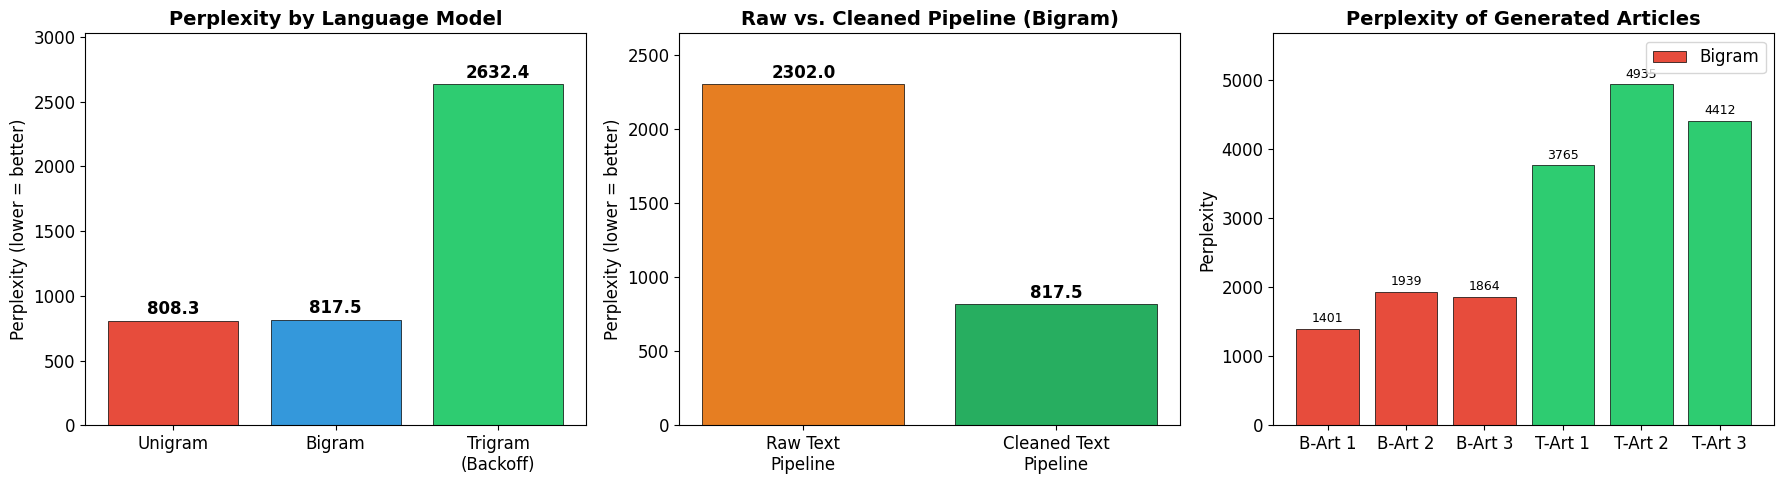


BACKOFF STATISTICS (Trigram Articles)

Article 1:
  Trigram used: 228 (97.9%)
  Bigram used:  5 (2.1%)
  Unigram used: 0 (0.0%)

Article 2:
  Trigram used: 215 (96.0%)
  Bigram used:  9 (4.0%)
  Unigram used: 0 (0.0%)

Article 3:
  Trigram used: 199 (97.5%)
  Bigram used:  5 (2.5%)
  Unigram used: 0 (0.0%)

SUMMARY TABLE
Metric                                        Value
--------------------------------------------------
Total articles scraped                          233
Total tokens                                359,626
Vocabulary size                              13,938
Training sentences                           13,349
Unigram perplexity                           808.30
Bigram perplexity                            817.47
Trigram perplexity (backoff)                2632.45
Raw pipeline perplexity                     2302.00
Cleaned pipeline perplexity                  817.47

✓ Evaluation and analysis complete!


In [ ]:

# Evaluation and Analysis


import math
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from IPython.display import HTML, display

# Configure matplotlib for better display
matplotlib.rcParams['figure.figsize'] = (12, 6)
matplotlib.rcParams['font.size'] = 12

# Perplexity Calculation Functions

def calculate_perplexity_unigram(tokens):
    """Calculate perplexity using the unigram model."""
    N = len(tokens)
    if N == 0:
        return float('inf')
    
    log_prob_sum = 0
    for token in tokens:
        prob = unigram_prob(token)
        if prob > 0:
            log_prob_sum += math.log2(prob)
        else:
            log_prob_sum += math.log2(1e-10)  # smoothed floor
    
    perplexity = 2 ** (-log_prob_sum / N)
    return perplexity

def calculate_perplexity_bigram(sentences):
    """Calculate perplexity using the bigram model."""
    total_log_prob = 0
    total_tokens = 0
    
    for sent_tokens in sentences:
        sent = ['<s>'] + sent_tokens + ['</s>']
        for i in range(1, len(sent)):
            prob = bigram_prob(sent[i], sent[i-1])
            if prob > 0:
                total_log_prob += math.log2(prob)
            else:
                total_log_prob += math.log2(1e-10)
            total_tokens += 1
    
    if total_tokens == 0:
        return float('inf')
    
    perplexity = 2 ** (-total_log_prob / total_tokens)
    return perplexity

def calculate_perplexity_trigram(sentences):
    """Calculate perplexity using the trigram model with backoff."""
    total_log_prob = 0
    total_tokens = 0
    
    for sent_tokens in sentences:
        sent = ['<s>', '<s>'] + sent_tokens + ['</s>']
        for i in range(2, len(sent)):
            w1, w2, w3 = sent[i-2], sent[i-1], sent[i]
            prob, _ = backoff_prob(w3, w1, w2)
            if prob > 0:
                total_log_prob += math.log2(prob)
            else:
                total_log_prob += math.log2(1e-10)
            total_tokens += 1
    
    if total_tokens == 0:
        return float('inf')
    
    perplexity = 2 ** (-total_log_prob / total_tokens)
    return perplexity

# 1. Perplexity on Training Data
print("=" * 60)
print("EVALUATION: PERPLEXITY SCORES")
print("=" * 60)

# Prepare test sentences from the training data (use last 10% as test)
test_start = int(len(all_sentences) * 0.9)
test_sentences = all_sentences[test_start:]
test_tokens_flat = [token for sent in test_sentences for token in sent if token not in ('<s>', '</s>')]
test_sent_tokens = [[t for t in sent if t not in ('<s>', '</s>')] for sent in test_sentences]

print(f"\nTest set: {len(test_sentences)} sentences, {len(test_tokens_flat)} tokens")

# Calculate perplexity for each model
pp_unigram = calculate_perplexity_unigram(test_tokens_flat)
pp_bigram = calculate_perplexity_bigram(test_sent_tokens)
pp_trigram = calculate_perplexity_trigram(test_sent_tokens)

print(f"\n--- Perplexity on Test Data ---")
print(f"  Unigram:               {pp_unigram:.2f}")
print(f"  Bigram:                {pp_bigram:.2f}")
print(f"  Trigram (with backoff): {pp_trigram:.2f}")

# 2. Perplexity on Generated Articles
print(f"\n--- Perplexity on Generated Articles ---")

for i, article in enumerate(bigram_articles, 1):
    tokens = [t for t in article['tokens'] if t not in SENTENCE_ENDERS and t != '<s>' and t != '</s>']
    pp = calculate_perplexity_unigram(tokens)
    pp_b = calculate_perplexity_bigram([tokens])
    print(f"  Bigram Article {i}:  Unigram PP={pp:.2f}, Bigram PP={pp_b:.2f}")

for i, article in enumerate(trigram_articles, 1):
    tokens = [t for t in article['tokens'] if t not in SENTENCE_ENDERS and t != '<s>' and t != '</s>']
    pp = calculate_perplexity_unigram(tokens)
    pp_t = calculate_perplexity_trigram([tokens])
    print(f"  Trigram Article {i}: Unigram PP={pp:.2f}, Trigram PP={pp_t:.2f}")

# 3. Raw vs Cleaned Pipeline Comparison
print(f"\n--- Raw vs. Cleaned Pipeline Comparison ---")

# Build a simple model on raw data for comparison
import json
raw_articles_data = {}
with open(os.path.join(output_dir, "articles_full.json"), 'r', encoding='utf-8') as f:
    raw_articles_data = json.load(f)

# Tokenize raw articles (minimal processing)
raw_sentences = []
for num in sorted(raw_articles_data.keys(), key=int):
    body = raw_articles_data[num]['body']
    lines = body.split('\n')
    for line in lines:
        line = line.strip()
        if line and len(line) > 10:
            tokens = line.split()
            if len(tokens) >= 3:
                raw_sentences.append(['<s>'] + tokens + ['</s>'])

# Build raw bigram model
raw_bigram_counts = defaultdict(lambda: defaultdict(int))
raw_bigram_context = defaultdict(int)
raw_unigram_counts = defaultdict(int)
raw_total = 0

for sent in raw_sentences:
    for i in range(len(sent) - 1):
        raw_bigram_counts[sent[i]][sent[i+1]] += 1
        raw_bigram_context[sent[i]] += 1
    for token in sent:
        if token != '<s>':
            raw_unigram_counts[token] += 1
            raw_total += 1

raw_vocab_size = len(raw_unigram_counts)

# Calculate perplexity on same test data using raw-trained model
raw_pp = 0
raw_tokens_count = 0
for sent_tokens in test_sent_tokens[:100]:
    sent = ['<s>'] + sent_tokens + ['</s>']
    for i in range(1, len(sent)):
        count = raw_bigram_counts[sent[i-1]][sent[i]] + 1
        context = raw_bigram_context[sent[i-1]] + raw_vocab_size
        prob = count / context if context > 0 else 1e-10
        raw_pp += math.log2(prob)
        raw_tokens_count += 1

raw_perplexity = 2 ** (-raw_pp / raw_tokens_count) if raw_tokens_count > 0 else float('inf')

# Cleaned model perplexity (already calculated)
clean_perplexity = pp_bigram

print(f"  Raw text pipeline (Bigram):     {raw_perplexity:.2f}")
print(f"  Cleaned text pipeline (Bigram): {clean_perplexity:.2f}")
print(f"  Improvement: {((raw_perplexity - clean_perplexity) / raw_perplexity * 100):.1f}%")

# 4. PLOTS

# Plot 1: Model Comparison - Perplexity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar chart: Model perplexity comparison
models = ['Unigram', 'Bigram', 'Trigram\n(Backoff)']
perplexities = [pp_unigram, pp_bigram, pp_trigram]
colors = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(models, perplexities, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Perplexity by Language Model', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Perplexity (lower = better)')
for i, v in enumerate(perplexities):
    axes[0].text(i, v + max(perplexities)*0.02, f'{v:.1f}', ha='center', fontweight='bold')
axes[0].set_ylim(0, max(perplexities) * 1.15)

# Plot 2: Raw vs Cleaned comparison  
pipelines = ['Raw Text\nPipeline', 'Cleaned Text\nPipeline']
pipeline_pp = [raw_perplexity, clean_perplexity]
colors2 = ['#e67e22', '#27ae60']

axes[1].bar(pipelines, pipeline_pp, color=colors2, edgecolor='black', linewidth=0.5)
axes[1].set_title('Raw vs. Cleaned Pipeline (Bigram)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Perplexity (lower = better)')
for i, v in enumerate(pipeline_pp):
    axes[1].text(i, v + max(pipeline_pp)*0.02, f'{v:.1f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, max(pipeline_pp) * 1.15)

# Plot 3: Generated article perplexity comparison
article_labels = [f'B-Art {i+1}' for i in range(3)] + [f'T-Art {i+1}' for i in range(3)]
article_pp = []
for article in bigram_articles:
    tokens = [t for t in article['tokens'] if t not in SENTENCE_ENDERS and t != '<s>' and t != '</s>']
    article_pp.append(calculate_perplexity_bigram([tokens]))
for article in trigram_articles:
    tokens = [t for t in article['tokens'] if t not in SENTENCE_ENDERS and t != '<s>' and t != '</s>']
    article_pp.append(calculate_perplexity_trigram([tokens]))

bar_colors = ['#e74c3c']*3 + ['#2ecc71']*3
axes[2].bar(article_labels, article_pp, color=bar_colors, edgecolor='black', linewidth=0.5)
axes[2].set_title('Perplexity of Generated Articles', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Perplexity')
axes[2].legend(['Bigram', 'Trigram'], loc='upper right')
for i, v in enumerate(article_pp):
    axes[2].text(i, v + max(article_pp)*0.02, f'{v:.0f}', ha='center', fontsize=9)
axes[2].set_ylim(0, max(article_pp) * 1.15)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'evaluation_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

# 5. Backoff Statistics Summary
print("\n" + "=" * 60)
print("BACKOFF STATISTICS (Trigram Articles)")
print("=" * 60)

for i, article in enumerate(trigram_articles, 1):
    stats = article['backoff_stats']
    total = sum(stats.values())
    print(f"\nArticle {i}:")
    print(f"  Trigram used: {stats['trigram']} ({stats['trigram']/total*100:.1f}%)")
    print(f"  Bigram used:  {stats['bigram']} ({stats['bigram']/total*100:.1f}%)")
    print(f"  Unigram used: {stats['unigram']} ({stats['unigram']/total*100:.1f}%)")

# 6. Summary Table
print("\n" + "=" * 60)
print("SUMMARY TABLE")
print("=" * 60)
print(f"{'Metric':<35} {'Value':>15}")
print("-" * 50)
print(f"{'Total articles scraped':<35} {len(tokenized_articles):>15}")
print(f"{'Total tokens':<35} {total_tokens:>15,}")
print(f"{'Vocabulary size':<35} {vocab_size:>15,}")
print(f"{'Training sentences':<35} {len(all_sentences):>15,}")
print(f"{'Unigram perplexity':<35} {pp_unigram:>15.2f}")
print(f"{'Bigram perplexity':<35} {pp_bigram:>15.2f}")
print(f"{'Trigram perplexity (backoff)':<35} {pp_trigram:>15.2f}")
print(f"{'Raw pipeline perplexity':<35} {raw_perplexity:>15.2f}")
print(f"{'Cleaned pipeline perplexity':<35} {clean_perplexity:>15.2f}")

print("\n✓ Evaluation and analysis complete!")